# Bab 1: Pendahuluan

Bab ini mencakup dasar-dasar pembelajaran mesin (machine learning), alasan mengapa Python dan scikit-learn menjadi alat pilihan,
dan memandu melalui contoh klasifikasi end-to-end pertama menggunakan dataset Iris.

**Topik yang dibahas:**

* Apa itu pembelajaran mesin dan masalah apa yang diselesaikannya
* Pustaka scikit-learn dan alat-alat penting (NumPy, SciPy, matplotlib, pandas)
* Dataset Iris sebagai masalah klasifikasi pertama
* Pembagian data pelatihan (training) dan pengujian (testing)
* Membangun dan mengevaluasi klasifikasi k-Nearest Neighbors

## 1.1 Mengapa Machine Learning?

Pemrograman tradisional mengharuskan seorang pakar untuk menulis aturan yang jelas untuk setiap keputusan.
Pembelajaran mesin sebaliknya mempelajari aturan dari data secara otomatis.

**Perbedaan utama:**

* Pemrograman tradisional: aturan + data = keluaran
* Pembelajaran mesin: data + keluaran = aturan (model mempelajari aturan tersebut)

Ini sangat berguna ketika aturannya terlalu rumit untuk ditulis secara manual oleh manusia, seperti mengenali wajah atau menyaring email spam.

## 1.2 Masalah yang Dapat Diselesaikan Pembelajaran Mesin

Masalah pembelajaran mesin secara garis besar dibagi menjadi dua kategori:

**Supervised Learning (Pembelajaran Terawasi)** - Algoritma belajar dari data pelatihan yang memiliki label (pasangan masukan-keluaran).

* Klasifikasi: memprediksi suatu kategori (contoh: spam/bukan spam)
* Regresi: memprediksi nilai kontinu (contoh: harga rumah)

**Unsupervised Learning (Pembelajaran Tanpa Pengawasan)** - Algoritma menemukan struktur atau pola pada data yang tidak memiliki label.

* Clustering (Pengelompokan): mengelompokkan titik data yang serupa secara bersamaan
* Reduksi dimensi: mengompresi data dengan tetap mempertahankan strukturnya

**Aturan utama:** Anda memerlukan data berlabel untuk melatih model supervised.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sp
import sklearn

print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Scikit-learn version:", sklearn.__version__)
print("SciPy version:", sp.__version__)

NumPy version: 2.0.2
Pandas version: 2.2.2
Scikit-learn version: 1.6.1
SciPy version: 1.16.3


## 1.3 NumPy

NumPy menyediakan larik multi-dimensi (multi-dimensional arrays) dan operasi matematika yang cepat.
Pustaka ini menjadi fondasi bagi hampir setiap pustaka ilmiah Python.

* `ndarray`: objek inti larik N-dimensi (N-dimensional array)
* Operasi tervektorisasi (vectorized operations) dijalankan dalam kode C yang terkompilasi, jauh lebih cepat daripada perulangan (loops) Python
* scikit-learn menerima dan mengembalikan larik NumPy sebagai format data utamanya

In [ ]:
x = np.array([[1, 2, 3],
               [4, 5, 6]])
print("Shape:", x.shape)
print("Data type:", x.dtype)
print("Number of dimensions:", x.ndim)
print("Total elements:", x.size)
print("Element-wise square:\n", x ** 2)
print("Row means:", x.mean(axis=1))

Shape: (2, 3)
Data type: int64
Number of dimensions: 2
Total elements: 6
Element-wise square:
 [[ 1  4  9]
 [16 25 36]]
Row means: [2. 5.]


## 1.4 SciPy

SciPy dikembangkan di atas NumPy dan menyediakan rutinitas komputasi ilmiah: optimasi, aljabar linier, statistika, pemrosesan sinyal, dan matriks jarang (sparse matrices).

scikit-learn menggunakan `scipy.sparse` untuk menyimpan data berdimensi tinggi secara efisien (seperti matriks fitur teks) yang sebagian besar berisi nilai nol.

In [ ]:
from scipy import sparse
eye = np.eye(5)
sparse_matrix = sparse.csr_matrix(eye)
print("Dense matrix shape:", eye.shape)
print("Sparse representation:\n", sparse_matrix)
print("Non-zero elements:", sparse_matrix.nnz)

Dense matrix shape: (5, 5)
Sparse representation:
 <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5 stored elements and shape (5, 5)>
  Coords	Values
  (0, 0)	1.0
  (1, 1)	1.0
  (2, 2)	1.0
  (3, 3)	1.0
  (4, 4)	1.0
Non-zero elements: 5


## 1.5 matplotlib

matplotlib adalah pustaka utama untuk membuat plot ilmiah dalam Python. Pustaka ini menyediakan fungsi untuk membuat visualisasi berkualitas tinggi seperti grafik garis, histogram, diagram pencar (scatter plots), dan banyak lagi. Memvisualisasikan data dan berbagai aspek dari model Anda dapat memberikan wawasan penting, dan matplotlib merupakan alat utama untuk analisis visual tersebut.

Saat bekerja di dalam Jupyter Notebook, Anda dapat menampilkan grafik secara langsung di dalam dokumen menggunakan perintah %matplotlib inline. Hal ini sangat memudahkan analisis eksploratif data secara interaktif tanpa perlu membuka jendela baru untuk menampilkan gambar.

Berikut adalah contoh pembuatan plot gelombang sinus menggunakan matplotlib:

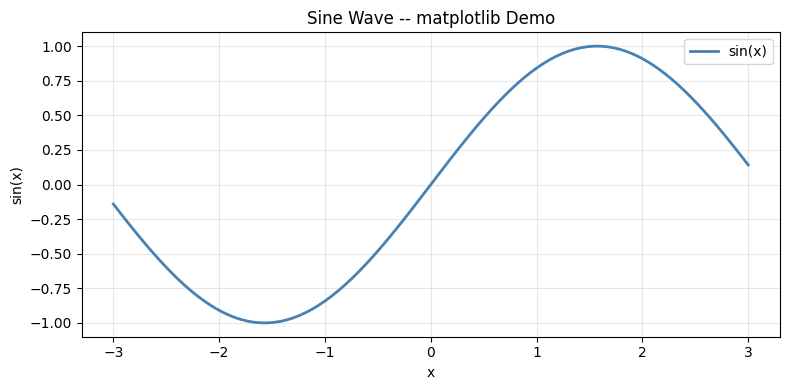

In [ ]:
x_vals = np.linspace(-3, 3, 100)
y_vals = np.sin(x_vals)
plt.figure(figsize=(8, 4))
plt.plot(x_vals, y_vals, label="sin(x)", color="steelblue", linewidth=2)
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.title("Sine Wave -- matplotlib Demo")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 1.6 pandas

pandas menyediakan `DataFrame`, sebuah struktur mirip tabel dengan baris dan kolom yang memiliki label. Pustaka ini sangat ideal untuk memuat, mengeksplorasi, dan membersihkan dataset sebelum dimasukkan ke dalam scikit-learn.

In [ ]:
df = pd.DataFrame({
    "Name": ["Alice", "Bob", "Carol"],
    "Age": [25, 30, 22],
    "Score": [88.5, 92.0, 78.3]
})
print(df)
print("\nData types:\n", df.dtypes)
print("\nBasic statistics:\n", df.describe())

    Name  Age  Score
0  Alice   25   88.5
1    Bob   30   92.0
2  Carol   22   78.3

Data types:
 Name      object
Age        int64
Score    float64
dtype: object

Basic statistics:
              Age      Score
count   3.000000   3.000000
mean   25.666667  86.266667
std     4.041452   7.117818
min    22.000000  78.300000
25%    23.500000  83.400000
50%    25.000000  88.500000
75%    27.500000  90.250000
max    30.000000  92.000000


## 1.7 Aplikasi Pertama: Mengklasifikasikan Spesies Iris

Dataset Iris adalah 'hello world' dalam pembelajaran mesin. Dataset ini berisi hasil pengukuran dari 150 bunga iris yang berasal dari tiga spesies.

**Fitur (masukan):** panjang sepal, lebar sepal, panjang kelopak (petal), lebar kelopak (semuanya dalam satuan cm)

**Target (keluaran):** spesies (setosa, versicolor, virginica)

**Tujuan:** berdasarkan hasil pengukuran dari bunga baru, prediksi apa spesiesnya.

In [ ]:
from sklearn.datasets import load_iris

iris = load_iris()
print("Type of iris_dataset:", type(iris))
print("\nKeys of iris_dataset:", list(iris.keys()))
print("\nShape of data:", iris["data"].shape)
print("\nFeature names:", iris["feature_names"])
print("Target names:", iris["target_names"])
print("\nFirst 5 samples:\n", iris["data"][:5])

Type of iris_dataset: <class 'sklearn.utils._bunch.Bunch'>

Keys of iris_dataset: ['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module']

Shape of data: (150, 4)

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']

First 5 samples:
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


## 1.8 Data Pelatihan dan Pengujian

**Masalah mendasar:** jika kita melatih dan menguji model menggunakan data yang sama, kita hanya mengukur kemampuan menghafal, bukan kemampuan generalisasi terhadap data baru.

**Solusi:** sisihkan sebagian data (sebagai data pengujian) sebelum proses pelatihan dimulai. Pembagian yang umum digunakan adalah 75% untuk data pelatihan / 25% untuk data pengujian.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    iris["data"], iris["target"],
    test_size=0.25,
    random_state=0
)
print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape: ", y_test.shape)
print("\nClass distribution in y_train:", np.bincount(y_train))
print("Class distribution in y_test: ", np.bincount(y_test))

X_train shape: (112, 4)
X_test shape:  (38, 4)
y_train shape: (112,)
y_test shape:  (38,)

Class distribution in y_train: [37 34 41]
Class distribution in y_test:  [13 16  9]


## 1.9 Periksa Data Anda

Sebelum membangun model apa pun, selalu lakukan visualisasi terhadap data Anda.
Sebuah matriks diagram pencar (scatter matrix) dapat mengungkapkan apakah kelas-kelas yang ada dapat dipisahkan di dalam ruang fitur (feature space).

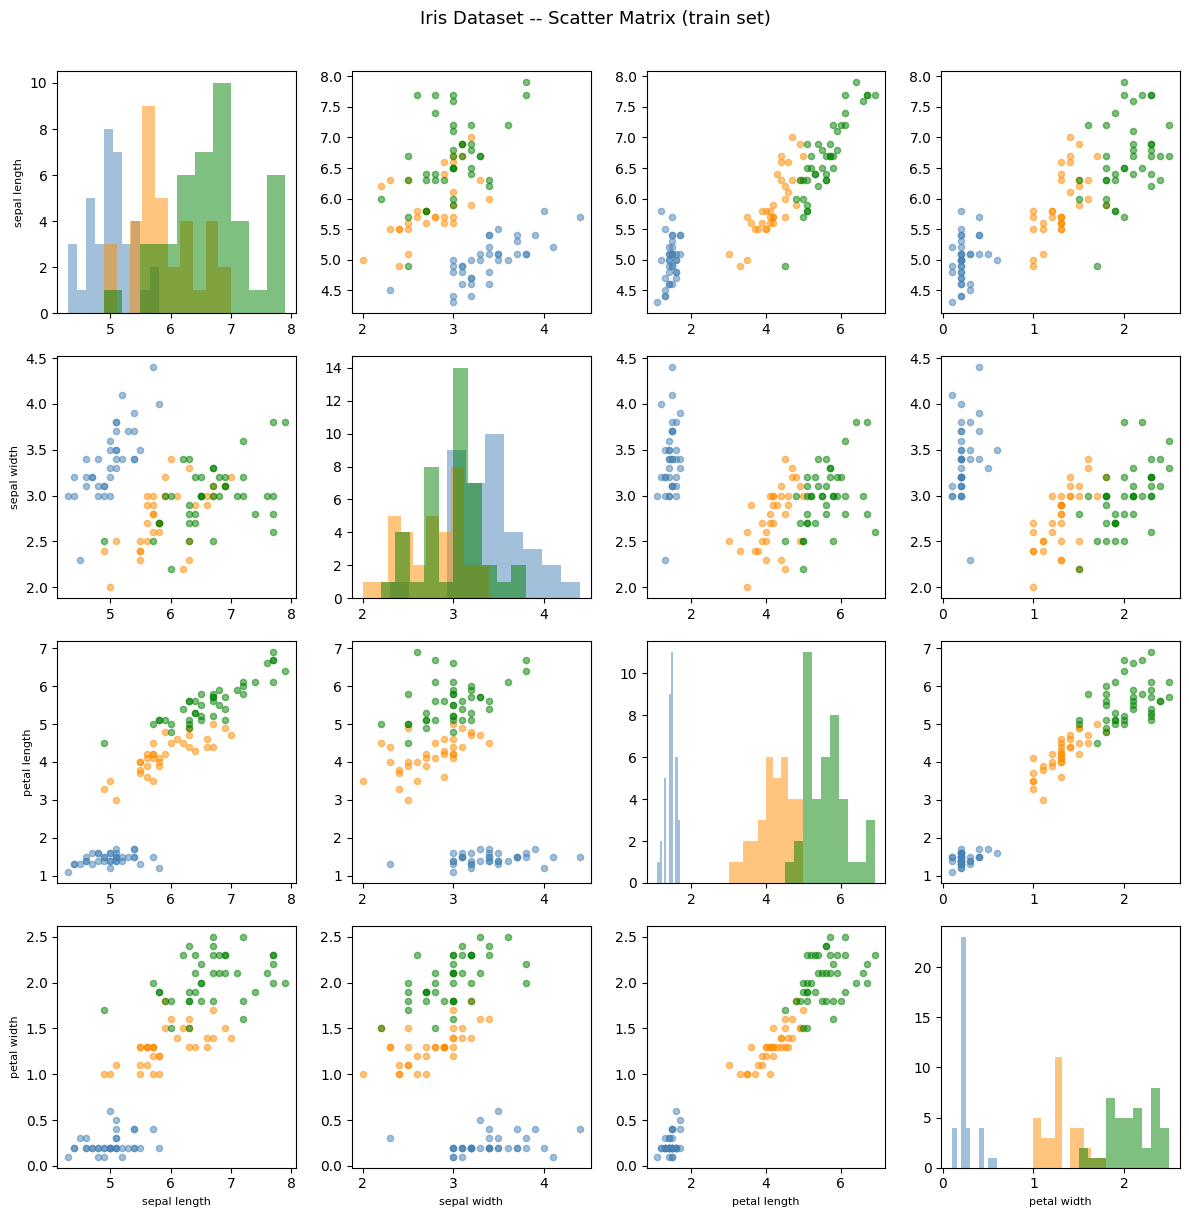

petal length and petal width separate the three species very well.


In [ ]:
iris_df = pd.DataFrame(X_train, columns=iris.feature_names)
colors = ["steelblue", "darkorange", "green"]
species = iris.target_names

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i, feat_i in enumerate(iris.feature_names):
    for j, feat_j in enumerate(iris.feature_names):
        ax = axes[i, j]
        if i == j:
            for cls in range(3):
                mask = y_train == cls
                ax.hist(X_train[mask, i], color=colors[cls], alpha=0.5, bins=10)
        else:
            for cls in range(3):
                mask = y_train == cls
                ax.scatter(X_train[mask, j], X_train[mask, i],
                           c=colors[cls], alpha=0.5, s=20)
        if i == 3:
            ax.set_xlabel(feat_j.replace(" (cm)", ""), fontsize=8)
        if j == 0:
            ax.set_ylabel(feat_i.replace(" (cm)", ""), fontsize=8)

plt.suptitle("Iris Dataset -- Scatter Matrix (train set)", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()
print("petal length and petal width separate the three species very well.")

## 1.10 Pengklasifikasi k-Nearest Neighbors (kNN)

**Algoritma:**

1. Menyimpan seluruh data contoh pelatihan (training examples).
2. Untuk suatu titik data baru, cari sebanyak k titik data pelatihan yang posisinya paling dekat dengan titik tersebut (menggunakan jarak Euclidean).
3. Kelas yang diprediksi ditentukan berdasarkan kelas mayoritas (suara terbanyak) di antara k tetangga terdekat tersebut.

**Hiperparameter utama:** k

* k kecil: batas keputusan kompleks, berisiko overfitting (terlalu menyesuaikan data pelatihan)
* k besar: batas keputusan halus, berisiko underfitting (terlalu menyederhanakan pola data)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)
print("Model trained. Object type:", type(knn))

X_new = np.array([[5.0, 2.9, 1.0, 0.2]])
prediction = knn.predict(X_new)
print("Prediction:", prediction)
print("Predicted target name:", iris["target_names"][prediction])

Model trained. Object type: <class 'sklearn.neighbors._classification.KNeighborsClassifier'>
Prediction: [0]
Predicted target name: ['setosa']


## 1.11 Evaluasi Model

Akurasi = (jumlah prediksi yang benar) / (total seluruh prediksi)

In [ ]:
y_pred = knn.predict(X_test)
accuracy = np.mean(y_pred == y_test)
print("Manually computed accuracy: {:.4f}".format(accuracy))
score = knn.score(X_test, y_test)
print("knn.score(X_test, y_test):  {:.4f}".format(score))

Manually computed accuracy: 0.9737
knn.score(X_test, y_test):  0.9737


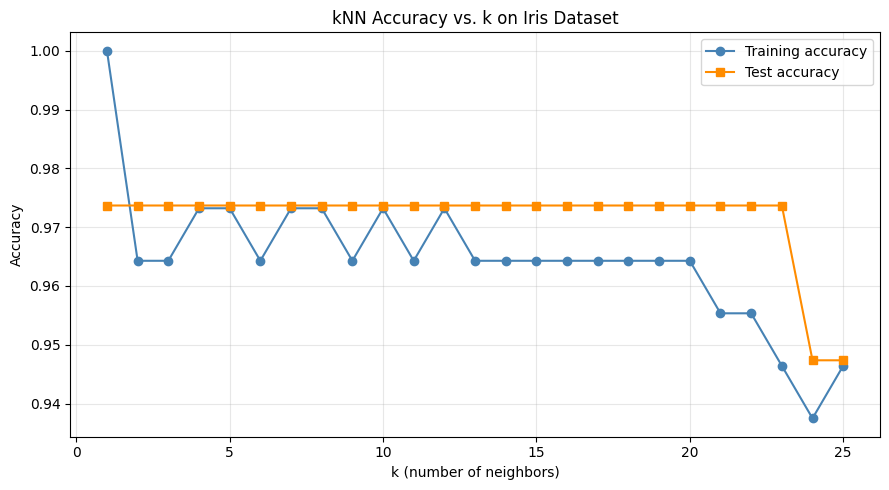

Best k: 1 with test accuracy: 0.9736842105263158


In [ ]:
train_scores = []
test_scores = []
k_values = range(1, 26)

for k in k_values:
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train, y_train)
    train_scores.append(clf.score(X_train, y_train))
    test_scores.append(clf.score(X_test, y_test))

plt.figure(figsize=(9, 5))
plt.plot(k_values, train_scores, label="Training accuracy", marker="o", color="steelblue")
plt.plot(k_values, test_scores,  label="Test accuracy",     marker="s", color="darkorange")
plt.xlabel("k (number of neighbors)")
plt.ylabel("Accuracy")
plt.title("kNN Accuracy vs. k on Iris Dataset")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k = list(k_values)[np.argmax(test_scores)]
print("Best k:", best_k, "with test accuracy:", max(test_scores))

## 1.12 Ringkasan

* Algoritma pembelajaran mesin (machine learning) mempelajari pola dari data alih-alih diprogram dengan aturan eksplisit secara manual.
* scikit-learn menyediakan API yang konsisten: `fit()` untuk melatih model, `predict()` untuk membuat prediksi, dan `score()` untuk mengevaluasi performa model.
* Disiplin paling penting dalam pembelajaran mesin adalah pembagian data pelatihan dan pengujian (train/test split). Selalu lakukan evaluasi model pada data yang belum pernah dilihat sebelumnya oleh model tersebut.
* kNN adalah pengklasifikasi pertama yang sangat intuitif: algoritma ini menentukan kelas berdasarkan suara mayoritas (majority vote) di antara k contoh data pelatihan terdekat.
* Pada dataset Iris, algoritma kNN mampu mencapai akurasi pengujian sekitar 97%.